In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./dataset/train.csv", index_col=0)
df["Sentence_id"] = df["Sentence_id"].ffill()
df.head(30)

,Sentence_id,Word,POS,Tag
0,1.0,Thousands,NNS,0
1,1.0,of,IN,0
2,1.0,demonstrators,NNS,0
3,1.0,have,VBP,0
4,1.0,marched,VBN,0
5,1.0,through,IN,0
6,1.0,London,NNP,7
7,1.0,to,TO,0
8,1.0,protest,VB,0
9,1.0,the,DT,0


In [4]:
def dataset_overview(df):

    print("Dataset shape:", df.shape)
    print("Number of sentences:", df["Sentence_id"].nunique())
    print("Number of tokens:", len(df))
    print("Unique words:", df["Word"].nunique())
    print("Unique POS tags:", df["POS"].nunique())
    print("Unique NER tags:", df["Tag"].nunique())

    print("\nMissing values:")
    print(df.isna().sum())

dataset_overview(df)

Dataset shape: (839364, 4)
Number of sentences: 38367
Number of tokens: 839364
Unique words: 32056
Unique POS tags: 42
Unique NER tags: 17

Missing values:
Sentence_id    0
Word           9
POS            0
Tag            0
dtype: int64


The dataset contains `839,364` tokens (words mainly) across `38,367` sentences. Only `9` missing values were found in the `Word` column, which were handled during preprocessing inside `codebase.model.dataset.NERDatasetProcessor`. The dataset includes `17` NER labels, indicating a `BIO`-style annotation scheme with multiple entity types, we reveal interpretation later.

Average sentence length: 21.877238251622487
Max sentence length: 104
Min sentence length: 1


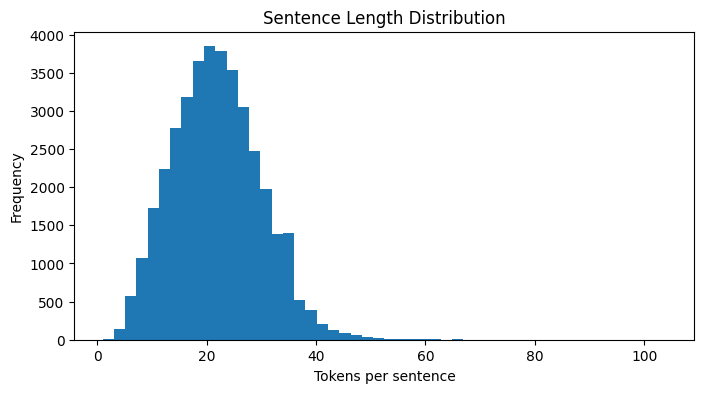

In [6]:
sentence_lengths = df.groupby("Sentence_id").size()

print("Average sentence length:", sentence_lengths.mean())
print("Max sentence length:", sentence_lengths.max())
print("Min sentence length:", sentence_lengths.min())

plt.figure(figsize=(8,4))
plt.hist(sentence_lengths, bins=50)
plt.title("Sentence Length Distribution")
plt.xlabel("Tokens per sentence")
plt.ylabel("Frequency")
plt.show()

The average sentence length in the dataset is approximately `22` tokens, with the longest sentence containing `104` tokens. The distribution is roughly normal with a slight right tail, indicating that most sentences are relatively short while a small number contain significantly more tokens. This observation supports the use of a fixed maximum sequence length during tokenization without excessive truncation.

Tag
0     710524
1      13573
2      13903
3      12662
4        155
5        252
6        206
7      30338
8       5987
9        164
10        45
11       321
12       241
13     16239
14      5152
15     16140
16     13462
Name: count, dtype: int64
Entity tokens: 128840
Non-entity tokens: 710524
Entity ratio: 15.35 %


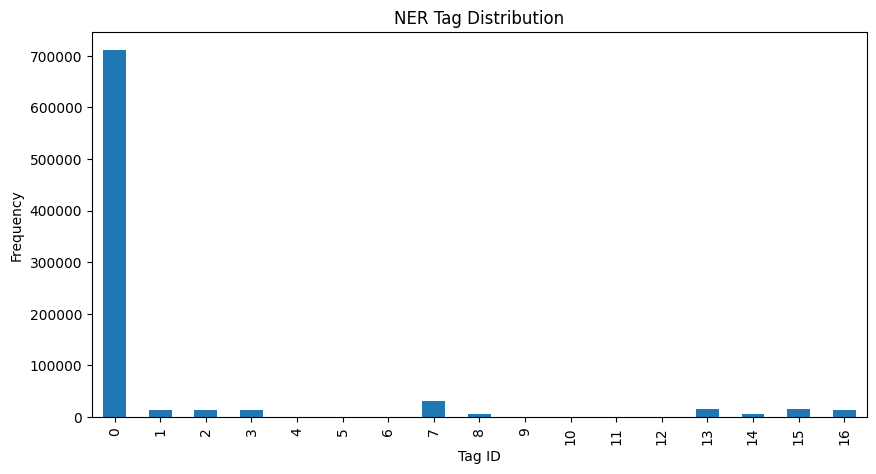

In [12]:
tag_counts = df["Tag"].value_counts().sort_index()

print(tag_counts)

entity_tokens = (df["Tag"] != 0).sum()
non_entity_tokens = (df["Tag"] == 0).sum()

print("Entity tokens:", entity_tokens)
print("Non-entity tokens:", non_entity_tokens)

print("Entity ratio:", round(entity_tokens / len(df) * 100, 2), "%")

tag_counts.plot(kind="bar", figsize=(10,5))
plt.title("NER Tag Distribution")
plt.xlabel("Tag ID")
plt.ylabel("Frequency")
plt.show()

The distribution of NER tags is expectedly highly imbalanced, with the `O` label (non-entity tokens) dominating the dataset. Entity-related tags occur significantly less frequently. This imbalance is typical for NER datasets and motivates the use of metrics such as precision, recall, and F1-score rather than accuracy when evaluating model performance.

In [ ]:
def print_unique_values(df):

    for col in df.columns:
        unique_vals = df[col].unique()
        print(f"\nColumn: {col}")
        print(f"Unique values count: {len(unique_vals)}")

        print(unique_vals[:20])

print_unique_values(df)


Column: Sentence_id
Unique values count: 38367
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 13. 14. 15. 17. 19. 21. 22.
 23. 24.]

Column: Word
Unique values count: 32057
['Thousands' 'of' 'demonstrators' 'have' 'marched' 'through' 'London' 'to'
 'protest' 'the' 'war' 'in' 'Iraq' 'and' 'demand' 'withdrawal' 'British'
 'troops' 'from' 'that']

Column: POS
Unique values count: 42
['NNS' 'IN' 'VBP' 'VBN' 'NNP' 'TO' 'VB' 'DT' 'NN' 'CC' 'JJ' '.' 'VBD' 'WP'
 '``' 'CD' 'PRP' 'VBZ' 'POS' 'VBG']

Column: Tag
Unique values count: 17
[ 0  7  3  1  8 15 16 13 11 12  2  4 14  9  5  6 10]


In [11]:
for tag, group in df.groupby("Tag"):
    print(f"\nTAG: {tag}")
    print(group.head(10)[["Word", "POS", "Tag"]])


TAG: 0
             Word  POS  Tag
0       Thousands  NNS    0
1              of   IN    0
2   demonstrators  NNS    0
3            have  VBP    0
4         marched  VBN    0
5         through   IN    0
7              to   TO    0
8         protest   VB    0
9             the   DT    0
10            war   NN    0

TAG: 1
           Word  POS  Tag
42         Bush  NNP    1
258   President  NNP    1
319      Thomas  NNP    1
387   President  NNP    1
805        Omar  NNP    1
829      Khayam  NNP    1
887      Khayam  NNP    1
937       Malik  NNP    1
1063      Abdul  NNP    1
1120       Khan  NNP    1

TAG: 2
             Word  POS  Tag
259       Mahmoud  NNP    2
260   Ahmadinejad  NNP    2
320       Horbach  NNP    2
388     Abdullahi  NNP    2
389         Yusuf  NNP    2
390         Ahmad  NNP    2
806        Khayam  NNP    2
938    Faridullah  NNP    2
939          Khan  NNP    2
1064       Qadeer  NNP    2

TAG: 3
        Word  POS  Tag
18   British   JJ    3
102  English   JJ   

We can analyze entities manually and determine the meaning of each one:

| Label | Tag | Meaning |
|:-:|:-:|-|
| `0` | `O` | Outside of entity |
| `1` | `B-per` | Beginning of `PERSON` |
| `2` | `I-per` | Continuation of `PERSON` |
| `3` | `B-gpe` | Beginning of `GPE` |
| `4` | `I-gpe` | Continuation of `GPE` |
| `5` | `B-eve` | Beginning of `EVENT` |
| `6` | `I-eve` | Continuation of `EVENT` |
| `7` | `B-geo` | Beginning of `LOCATION` |
| `8` | `I-geo` | Continuation of `LOCATION` |
| `9` | `B-nat` | Beginning of `DESIGNATION` |
| `10` | `I-nat` | Continuation of `DESIGNATION` |
| `11` | `B-art` | Beginning of `OBJECT` |
| `12` | `I-art` | Continuation of `OBJECT` |
| `13` | `B-tim` | Beginning of `DATETIME` |
| `14` | `I-tim` | Continuation of `DATETIME` |
| `15` | `B-org` | Beginning of `ORGANIZATION` |
| `16` | `I-org` | Continuation of `ORGANIZATION` |